# 04 — MMASH Sleep and Mental Health Analysis

This notebook analyzes the processed MMASH modeling dataset and explores relationships between sleep-related features, lifestyle variables and mental health indicators.

## Objectives

- load the prepared MMASH modeling dataset;
- inspect sleep, lifestyle and questionnaire-related variables;
- explore associations between sleep features and daily stress;
- train baseline regression models for exploratory prediction;
- interpret the limitations of the results.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start=Path.cwd()):
    for path in [start, *start.parents]:
        if (path / "README.md").exists() and (path / "data").exists():
            return path

    raise FileNotFoundError(
        "Project root not found. Make sure README.md and data/ exist."
    )


PROJECT_ROOT = find_project_root()

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
EXTERNAL_DIR = PROJECT_ROOT / "data" / "external"
FIGURES_DIR = PROJECT_ROOT / "figures"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

print("PROJECT_ROOT =", PROJECT_ROOT)
print("RAW_DIR =", RAW_DIR)
print("PROCESSED_DIR =", PROCESSED_DIR)

PROJECT_ROOT = C:\Users\vi\Sleep-clean
RAW_DIR = C:\Users\vi\Sleep-clean\data\raw
PROCESSED_DIR = C:\Users\vi\Sleep-clean\data\processed


In [2]:
mmash_path = PROCESSED_DIR / "mmash_modeling_dataset.csv"

if not mmash_path.exists():
    raise FileNotFoundError(
        f"File not found: {mmash_path}\n"
        "Place mmash_modeling_dataset.csv into data/processed/."
    )

mmash_df = pd.read_csv(mmash_path)

print("MMASH dataset shape:", mmash_df.shape)
mmash_df.head()

MMASH dataset shape: (22, 35)


,Latency,Efficiency,Total Minutes in Bed,Total Sleep Time (TST),Wake After Sleep Onset (WASO),Number of Awakenings,Average Awakening Length,Movement Index,Fragmentation Index,Sleep Fragmentation Index,...,panas_pos_9+1,panas_neg_10,panas_neg_14,panas_neg_18,panas_neg_22,panas_neg_9+1,Gender,Weight,Height,Age
0,0.0,89.645,189.0,170.0,19.0,9.0,2.11,9.0055,5.000,14.0055,...,17.0,11.0,13.0,13.0,10.0,10.0,M,65,169,29
1,4.0,75.080,329.0,247.0,78.0,13.0,6.00,20.6690,7.692,28.3610,...,23.0,15.0,23.0,23.0,27.0,12.0,M,85,180,27
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.0,15.0,15.0,11.0,13.0,14.0,M,115,186,27
3,0.0,94.230,364.0,343.0,21.0,12.0,1.75,9.0660,15.385,24.4510,...,29.0,14.0,16.0,14.0,23.0,13.0,M,67,170,27
4,0.0,76.470,323.0,247.0,76.0,19.0,4.00,17.9570,15.789,33.7460,...,23.0,13.0,NaN,11.0,13.0,12.0,M,74,180,25


In [3]:
mmash_path = PROCESSED_DIR / "mmash_modeling_dataset.csv"

if not mmash_path.exists():
    raise FileNotFoundError(
        f"File not found: {mmash_path}\n"
        "Place mmash_modeling_dataset.csv into data/processed/ or run the raw MMASH processing pipeline first."
    )

mmash_df = pd.read_csv(mmash_path)

print("MMASH dataset shape:", mmash_df.shape)
mmash_df.head()

MMASH dataset shape: (22, 35)


,Latency,Efficiency,Total Minutes in Bed,Total Sleep Time (TST),Wake After Sleep Onset (WASO),Number of Awakenings,Average Awakening Length,Movement Index,Fragmentation Index,Sleep Fragmentation Index,...,panas_pos_9+1,panas_neg_10,panas_neg_14,panas_neg_18,panas_neg_22,panas_neg_9+1,Gender,Weight,Height,Age
0,0.0,89.645,189.0,170.0,19.0,9.0,2.11,9.0055,5.000,14.0055,...,17.0,11.0,13.0,13.0,10.0,10.0,M,65,169,29
1,4.0,75.080,329.0,247.0,78.0,13.0,6.00,20.6690,7.692,28.3610,...,23.0,15.0,23.0,23.0,27.0,12.0,M,85,180,27
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.0,15.0,15.0,11.0,13.0,14.0,M,115,186,27
3,0.0,94.230,364.0,343.0,21.0,12.0,1.75,9.0660,15.385,24.4510,...,29.0,14.0,16.0,14.0,23.0,13.0,M,67,170,27
4,0.0,76.470,323.0,247.0,76.0,19.0,4.00,17.9570,15.789,33.7460,...,23.0,13.0,NaN,11.0,13.0,12.0,M,74,180,25


In [4]:
def read_csv_from_folder(path, filename=None):
    """Read a CSV file from a direct path or find it inside a folder."""
    path = Path(path)

    if filename is None:
        if path.exists():
            return pd.read_csv(path)

        matches = list(path.parent.rglob(path.name))
        if matches:
            return pd.read_csv(matches[0])

        raise FileNotFoundError(f"File not found: {path}")

    direct_path = path / filename
    if direct_path.exists():
        return pd.read_csv(direct_path)

    matches = list(path.rglob(filename))
    if matches:
        return pd.read_csv(matches[0])

    raise FileNotFoundError(
        f"File {filename} was not found inside {path}"
    )

In [5]:
import os
from pathlib import Path

print("Current working directory:", os.getcwd())
print("\nFiles here:")
for p in Path('.').iterdir():
    print(p.name)

Current working directory: C:\Users\vi\Sleep-clean\notebooks

Files here:
.ipynb_checkpoints
01_sleep_edf_exploration.ipynb
02_sleep_edf_build_dataset.ipynb
03_sleep_edf_feature_engineering.ipynb
04_mmash_sleep_mental_health.ipynb
05_sleep_deprivation_cognition.ipynb


In [6]:
from pathlib import Path

for p in Path('.').iterdir():
    print(p)

.ipynb_checkpoints
01_sleep_edf_exploration.ipynb
02_sleep_edf_build_dataset.ipynb
03_sleep_edf_feature_engineering.ipynb
04_mmash_sleep_mental_health.ipynb
05_sleep_deprivation_cognition.ipynb


In [7]:
from pathlib import Path

search_roots = [
    Path(r'C:\Users\vi\Downloads'),
    Path(r'C:\Users\vi\Desktop'),
    Path(r'C:\Users\vi\Documents'),
    Path(r'C:\Users\vi'),
]

matches = []

for root in search_roots:
    if root.exists():
        for p in root.rglob('user_info.csv'):
            matches.append(p)

print(f'Found {len(matches)} matches')
for p in matches[:50]:
    print(p)

Found 44 matches
C:\Users\vi\Sleep-clean\data\raw\mmash\DataPaper\user_1\user_info.csv
C:\Users\vi\Sleep-clean\data\raw\mmash\DataPaper\user_10\user_info.csv
C:\Users\vi\Sleep-clean\data\raw\mmash\DataPaper\user_11\user_info.csv
C:\Users\vi\Sleep-clean\data\raw\mmash\DataPaper\user_12\user_info.csv
C:\Users\vi\Sleep-clean\data\raw\mmash\DataPaper\user_13\user_info.csv
C:\Users\vi\Sleep-clean\data\raw\mmash\DataPaper\user_14\user_info.csv
C:\Users\vi\Sleep-clean\data\raw\mmash\DataPaper\user_15\user_info.csv
C:\Users\vi\Sleep-clean\data\raw\mmash\DataPaper\user_16\user_info.csv
C:\Users\vi\Sleep-clean\data\raw\mmash\DataPaper\user_17\user_info.csv
C:\Users\vi\Sleep-clean\data\raw\mmash\DataPaper\user_18\user_info.csv
C:\Users\vi\Sleep-clean\data\raw\mmash\DataPaper\user_19\user_info.csv
C:\Users\vi\Sleep-clean\data\raw\mmash\DataPaper\user_2\user_info.csv
C:\Users\vi\Sleep-clean\data\raw\mmash\DataPaper\user_20\user_info.csv
C:\Users\vi\Sleep-clean\data\raw\mmash\DataPaper\user_21\user_

In [8]:
import pandas as pd
import numpy as np

def read_csv_from_folder(path):
    return pd.read_csv(path)

In [9]:
mmash_df.to_csv(PROCESSED_DIR / 'mmash_modeling_dataset.csv', index=False)
print('Saved: mmash_modeling_dataset.csv')

Saved: mmash_modeling_dataset.csv


In [10]:
import pandas as pd

mmash_df = pd.read_csv(PROCESSED_DIR / 'mmash_modeling_dataset.csv')
print(mmash_df.shape)
mmash_df.head()

(22, 35)


,Latency,Efficiency,Total Minutes in Bed,Total Sleep Time (TST),Wake After Sleep Onset (WASO),Number of Awakenings,Average Awakening Length,Movement Index,Fragmentation Index,Sleep Fragmentation Index,...,panas_pos_9+1,panas_neg_10,panas_neg_14,panas_neg_18,panas_neg_22,panas_neg_9+1,Gender,Weight,Height,Age
0,0.0,89.645,189.0,170.0,19.0,9.0,2.11,9.0055,5.000,14.0055,...,17.0,11.0,13.0,13.0,10.0,10.0,M,65,169,29
1,4.0,75.080,329.0,247.0,78.0,13.0,6.00,20.6690,7.692,28.3610,...,23.0,15.0,23.0,23.0,27.0,12.0,M,85,180,27
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.0,15.0,15.0,11.0,13.0,14.0,M,115,186,27
3,0.0,94.230,364.0,343.0,21.0,12.0,1.75,9.0660,15.385,24.4510,...,29.0,14.0,16.0,14.0,23.0,13.0,M,67,170,27
4,0.0,76.470,323.0,247.0,76.0,19.0,4.00,17.9570,15.789,33.7460,...,23.0,13.0,NaN,11.0,13.0,12.0,M,74,180,25


In [11]:
mmash_df.columns.tolist()

['Latency',
 'Efficiency',
 'Total Minutes in Bed',
 'Total Sleep Time (TST)',
 'Wake After Sleep Onset (WASO)',
 'Number of Awakenings',
 'Average Awakening Length',
 'Movement Index',
 'Fragmentation Index',
 'Sleep Fragmentation Index',
 'user_id',
 'n_sleep_rows',
 'MEQ',
 'STAI1',
 'STAI2',
 'Pittsburgh',
 'Daily_stress',
 'BISBAS_bis',
 'BISBAS_reward',
 'BISBAS_drive',
 'BISBAS_fun',
 'panas_pos_10',
 'panas_pos_14',
 'panas_pos_18',
 'panas_pos_22',
 'panas_pos_9+1',
 'panas_neg_10',
 'panas_neg_14',
 'panas_neg_18',
 'panas_neg_22',
 'panas_neg_9+1',
 'Gender',
 'Weight',
 'Height',
 'Age']

In [12]:
mmash_df.isna().mean().sort_values(ascending=False)

Latency                          0.045455
Efficiency                       0.045455
Total Minutes in Bed             0.045455
Total Sleep Time (TST)           0.045455
Wake After Sleep Onset (WASO)    0.045455
Number of Awakenings             0.045455
Average Awakening Length         0.045455
Movement Index                   0.045455
Fragmentation Index              0.045455
Sleep Fragmentation Index        0.045455
panas_pos_14                     0.045455
panas_neg_14                     0.045455
MEQ                              0.000000
n_sleep_rows                     0.000000
STAI2                            0.000000
Pittsburgh                       0.000000
Daily_stress                     0.000000
STAI1                            0.000000
user_id                          0.000000
BISBAS_reward                    0.000000
BISBAS_bis                       0.000000
BISBAS_fun                       0.000000
BISBAS_drive                     0.000000
panas_pos_18                     0

In [13]:
target_col = 'Daily_stress'

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

target_col = 'Daily_stress'

feature_cols = [
    'Latency',
    'Efficiency',
    'Total Minutes in Bed',
    'Total Sleep Time (TST)',
    'Wake After Sleep Onset (WASO)',
    'Number of Awakenings',
    'Average Awakening Length',
    'Movement Index',
    'Fragmentation Index',
    'Sleep Fragmentation Index',
    'Age',
    'Weight',
    'Height',
    'Gender'
]

X = mmash_df[feature_cols].copy()
y = mmash_df[target_col].copy()

categorical_features = ['Gender']
numeric_features = [c for c in feature_cols if c not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

ridge_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

print('Ridge MAE:', mean_absolute_error(y_test, ridge_pred))
print('Ridge R2:', r2_score(y_test, ridge_pred))

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print('RF MAE:', mean_absolute_error(y_test, rf_pred))
print('RF R2:', r2_score(y_test, rf_pred))

Ridge MAE: 16.88781246844457
Ridge R2: -8.610304184530971
RF MAE: 14.916508597883592
RF R2: -4.881204970336396


In [15]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mae = -cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring='neg_mean_absolute_error'
)

cv_r2 = cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring='r2'
)

print('CV MAE:', cv_mae)
print('Mean CV MAE:', cv_mae.mean())

print('CV R2:', cv_r2)
print('Mean CV R2:', cv_r2.mean())

CV MAE: [14.27011032 14.41844656 13.95532044 10.72167163 15.39216964]
Mean CV MAE: 13.751543716931213
CV R2: [-4.40324846 -0.17738878 -0.37911504 -1.80697707 -0.30649555]
Mean CV R2: -1.414644979515033


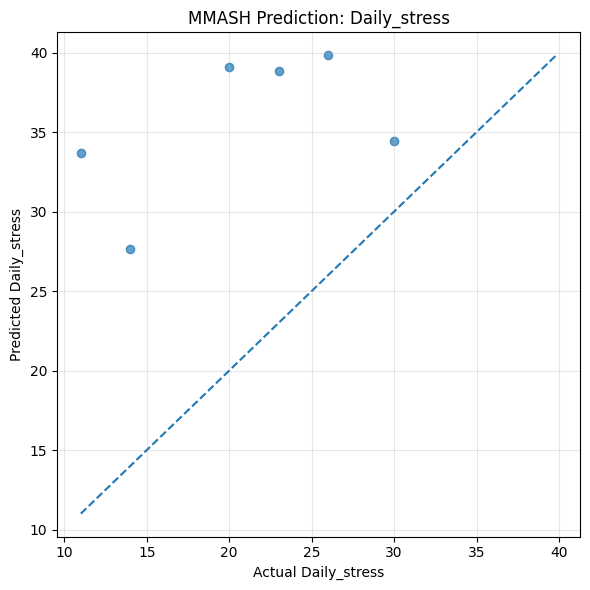

In [16]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, rf_pred, alpha=0.7)
plt.xlabel(f'Actual {target_col}')
plt.ylabel(f'Predicted {target_col}')
plt.title(f'MMASH Prediction: {target_col}')
plt.grid(alpha=0.3)

min_val = min(y_test.min(), rf_pred.min())
max_val = max(y_test.max(), rf_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.tight_layout()
plt.show()

In [17]:
corr_cols = [
    'Latency',
    'Efficiency',
    'Total Sleep Time (TST)',
    'Wake After Sleep Onset (WASO)',
    'Number of Awakenings',
    'Fragmentation Index',
    'Sleep Fragmentation Index',
    'Daily_stress',
    'STAI1',
    'STAI2',
    'Pittsburgh'
]

corr = mmash_df[corr_cols].corr(numeric_only=True)
corr['Daily_stress'].sort_values(ascending=False)

Daily_stress                     1.000000
Fragmentation Index              0.518555
Sleep Fragmentation Index        0.456675
Number of Awakenings             0.220139
Total Sleep Time (TST)           0.212188
Wake After Sleep Onset (WASO)    0.160180
Pittsburgh                       0.065829
STAI1                            0.015243
Efficiency                      -0.019071
Latency                         -0.184878
STAI2                           -0.420747
Name: Daily_stress, dtype: float64

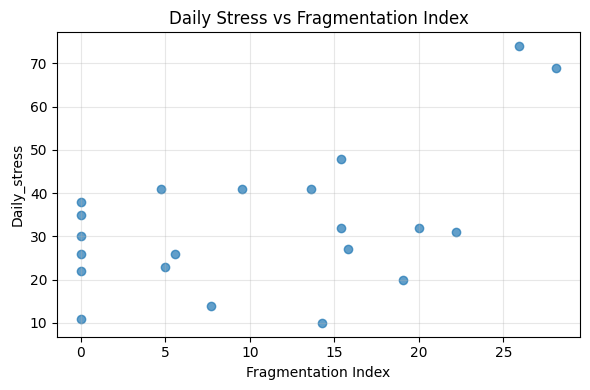

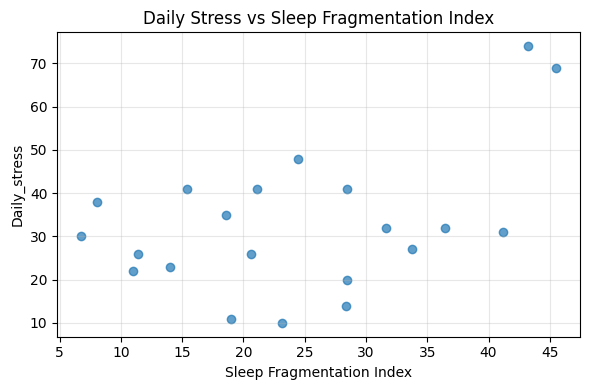

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(mmash_df['Fragmentation Index'], mmash_df['Daily_stress'], alpha=0.7)
plt.xlabel('Fragmentation Index')
plt.ylabel('Daily_stress')
plt.title('Daily Stress vs Fragmentation Index')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(mmash_df['Sleep Fragmentation Index'], mmash_df['Daily_stress'], alpha=0.7)
plt.xlabel('Sleep Fragmentation Index')
plt.ylabel('Daily_stress')
plt.title('Daily Stress vs Sleep Fragmentation Index')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Preliminary correlation analysis suggests that higher sleep fragmentation is associated with higher daily stress in MMASH participants. Fragmentation-related metrics showed stronger associations with stress than total sleep time, efficiency, or latency

In [19]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

target_col = 'Daily_stress'

feature_cols = [
    'Latency',
    'Efficiency',
    'Total Minutes in Bed',
    'Total Sleep Time (TST)',
    'Wake After Sleep Onset (WASO)',
    'Number of Awakenings',
    'Average Awakening Length',
    'Movement Index',
    'Fragmentation Index',
    'Sleep Fragmentation Index',
    'Age',
    'Weight',
    'Height',
    'Gender'
]

X = mmash_df[feature_cols].copy()
y = mmash_df[target_col].copy()

categorical_features = ['Gender']
numeric_features = [c for c in feature_cols if c not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

ridge_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

print('Ridge MAE:', mean_absolute_error(y_test, ridge_pred))
print('Ridge R2:', r2_score(y_test, ridge_pred))

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print('RF MAE:', mean_absolute_error(y_test, rf_pred))
print('RF R2:', r2_score(y_test, rf_pred))

Ridge MAE: 16.88781246844457
Ridge R2: -8.610304184530971
RF MAE: 14.916508597883592
RF R2: -4.881204970336396


In [20]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mae = -cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring='neg_mean_absolute_error'
)

cv_r2 = cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring='r2'
)

print('CV MAE:', cv_mae)
print('Mean CV MAE:', cv_mae.mean())

print('CV R2:', cv_r2)
print('Mean CV R2:', cv_r2.mean())

CV MAE: [14.27011032 14.41844656 13.95532044 10.72167163 15.39216964]
Mean CV MAE: 13.751543716931213
CV R2: [-4.40324846 -0.17738878 -0.37911504 -1.80697707 -0.30649555]
Mean CV R2: -1.414644979515033


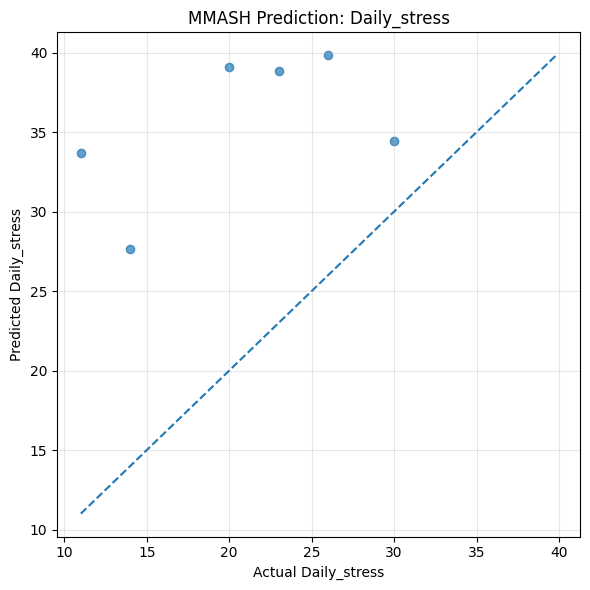

In [21]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, rf_pred, alpha=0.7)
plt.xlabel(f'Actual {target_col}')
plt.ylabel(f'Predicted {target_col}')
plt.title(f'MMASH Prediction: {target_col}')
plt.grid(alpha=0.3)

min_val = min(y_test.min(), rf_pred.min())
max_val = max(y_test.max(), rf_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.tight_layout()
plt.show()

## Model interpretation

A baseline regression model was trained to predict Daily_stress from sleep-related metrics and basic demographic variables.

Given the small sample size, model performance should be interpreted cautiously. The purpose of this analysis is exploratory: to test whether sleep quality metrics contain predictive signal for stress-related questionnaire outcomes.


Baseline regression models showed weak predictive performance for `Daily_stress` in this MMASH sample.

Although correlation analysis suggested that sleep fragmentation metrics were associated with daily stress, the predictive models did not generalize well. Both Ridge regression and Random Forest produced negative R² values, indicating that the models performed worse than a simple mean-based baseline.

This suggests that, in this small sample, sleep metrics alone do not provide a strong enough signal for robust prediction of daily stress.

## I explored whether sleep quality metrics contain predictive signal for stress-related questionnaire outcomes.
In MMASH, fragmentation-related metrics showed the strongest associations with daily stress, but baseline models did not generalize well, highlighting both the promise and the limitations of small open wearable datasets.

## Conclusion

This MMASH case study suggests that sleep fragmentation metrics may be associated with higher daily stress at the correlation level. However, baseline regression models showed poor generalization performance, with negative R² values across both hold-out and cross-validation settings.

These results indicate that sleep metrics alone are insufficient for robust stress prediction in this small sample. The analysis is therefore best interpreted as an exploratory proof of concept rather than a reliable predictive model.

In [22]:
for target in ['STAI1', 'Pittsburgh']:
    print(f'\nCorrelations with {target}')
    print(
        mmash_df[
            [
                'Latency',
                'Efficiency',
                'Total Sleep Time (TST)',
                'Wake After Sleep Onset (WASO)',
                'Number of Awakenings',
                'Fragmentation Index',
                'Sleep Fragmentation Index',
                target
            ]
        ].corr(numeric_only=True)[target].sort_values(ascending=False)
    )


Correlations with STAI1
STAI1                            1.000000
Efficiency                       0.484292
Total Sleep Time (TST)          -0.028398
Number of Awakenings            -0.325892
Latency                         -0.376190
Sleep Fragmentation Index       -0.403771
Fragmentation Index             -0.429233
Wake After Sleep Onset (WASO)   -0.489887
Name: STAI1, dtype: float64

Correlations with Pittsburgh
Pittsburgh                       1.000000
Total Sleep Time (TST)           0.358460
Wake After Sleep Onset (WASO)    0.202428
Latency                          0.089411
Efficiency                      -0.098475
Number of Awakenings            -0.202500
Sleep Fragmentation Index       -0.241033
Fragmentation Index             -0.279809
Name: Pittsburgh, dtype: float64


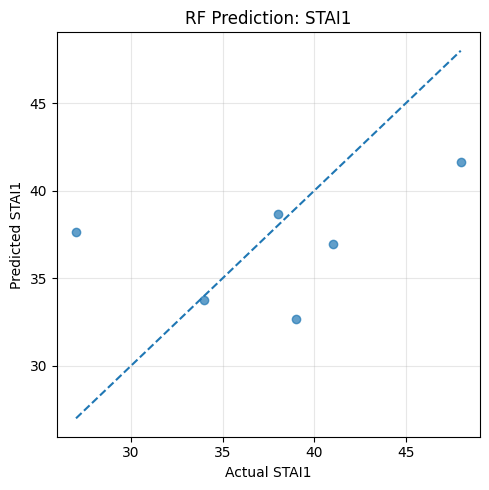

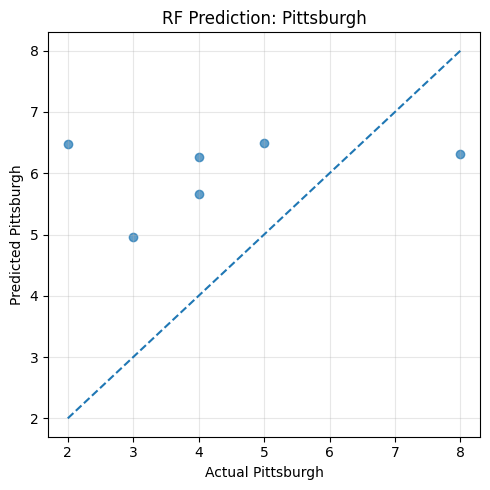

,target,ridge_mae,ridge_r2,rf_mae,rf_r2,cv_mae_mean,cv_r2_mean
0,STAI1,7.347507,-0.616938,4.725337,0.144167,6.238602,-0.257742
1,Pittsburgh,1.910331,-0.372124,2.257509,-0.728899,1.608456,-0.412711


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

feature_cols = [
    'Latency',
    'Efficiency',
    'Total Minutes in Bed',
    'Total Sleep Time (TST)',
    'Wake After Sleep Onset (WASO)',
    'Number of Awakenings',
    'Average Awakening Length',
    'Movement Index',
    'Fragmentation Index',
    'Sleep Fragmentation Index',
    'Age',
    'Weight',
    'Height',
    'Gender'
]

categorical_features = ['Gender']
numeric_features = [c for c in feature_cols if c not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ]
)

targets = ['STAI1', 'Pittsburgh']
results = []

for target_col in targets:
    X = mmash_df[feature_cols].copy()
    y = mmash_df[target_col].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42
    )

    ridge_model = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Ridge())
    ])

    ridge_model.fit(X_train, y_train)
    ridge_pred = ridge_model.predict(X_test)

    rf_model = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=2,
            random_state=42
        ))
    ])

    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_test)

    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    cv_mae = -cross_val_score(
        rf_model,
        X,
        y,
        cv=cv,
        scoring='neg_mean_absolute_error'
    )

    cv_r2 = cross_val_score(
        rf_model,
        X,
        y,
        cv=cv,
        scoring='r2'
    )

    results.append({
        'target': target_col,
        'ridge_mae': mean_absolute_error(y_test, ridge_pred),
        'ridge_r2': r2_score(y_test, ridge_pred),
        'rf_mae': mean_absolute_error(y_test, rf_pred),
        'rf_r2': r2_score(y_test, rf_pred),
        'cv_mae_mean': cv_mae.mean(),
        'cv_r2_mean': cv_r2.mean()
    })

    plt.figure(figsize=(5, 5))
    plt.scatter(y_test, rf_pred, alpha=0.7)
    plt.xlabel(f'Actual {target_col}')
    plt.ylabel(f'Predicted {target_col}')
    plt.title(f'RF Prediction: {target_col}')
    plt.grid(alpha=0.3)

    min_val = min(y_test.min(), rf_pred.min())
    max_val = max(y_test.max(), rf_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results)
results_df

## Target comparison interpretation

Among the tested questionnaire outcomes, `STAI1` showed the most promising predictive signal from sleep-related features. The Random Forest baseline achieved a small positive hold-out R², suggesting that sleep metrics may contain limited information about state anxiety in this sample.

In contrast, `Daily_stress` and `Pittsburgh` were not predicted robustly, especially under cross-validation. This indicates that, in MMASH, aggregated sleep features may be more informative for some anxiety-related measures than for broader stress or sleep-quality questionnaire scores.

In [24]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

target_col = 'STAI1'

X = mmash_df[feature_cols].copy()
y = mmash_df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

perm = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring='r2'
)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': perm.importances_mean
}).sort_values('importance_mean', ascending=False)

importance_df

,feature,importance_mean
1,Efficiency,0.340435
8,Fragmentation Index,0.043910
11,Weight,0.043211
4,Wake After Sleep Onset (WASO),0.031820
7,Movement Index,0.015730
0,Latency,0.011863
13,Gender,0.000000
12,Height,-0.000669
5,Number of Awakenings,-0.004754
9,Sleep Fragmentation Index,-0.007692


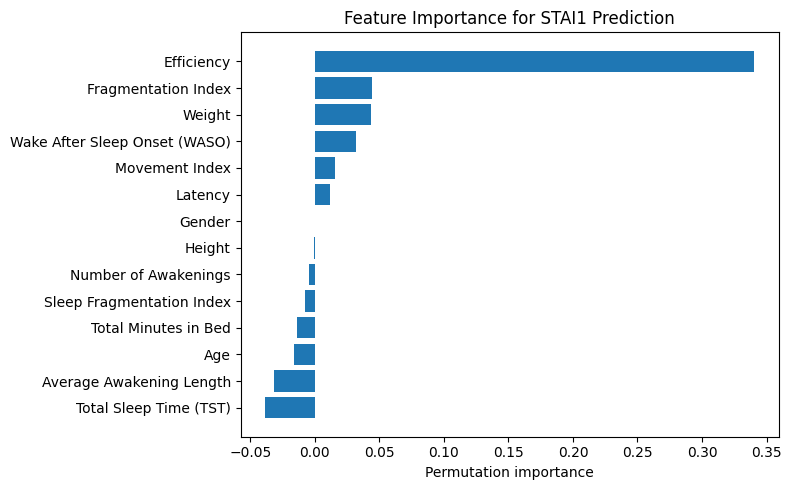

In [25]:
plt.figure(figsize=(8, 5))
plt.barh(importance_df['feature'], importance_df['importance_mean'])
plt.gca().invert_yaxis()
plt.xlabel('Permutation importance')
plt.title('Feature Importance for STAI1 Prediction')
plt.tight_layout()
plt.show()

In [26]:
mmash_df.to_csv(PROCESSED_DIR / 'mmash_modeling_dataset.csv', index=False)
print('Saved:', PROCESSED_DIR / 'mmash_modeling_dataset.csv')

Saved: C:\Users\vi\Sleep-clean\data\processed\mmash_modeling_dataset.csv


In [27]:
mmash_df.to_csv(PROCESSED_DIR / 'mmash_modeling_dataset.csv', index=False)
print('Saved:', PROCESSED_DIR / 'mmash_modeling_dataset.csv')

Saved: C:\Users\vi\Sleep-clean\data\processed\mmash_modeling_dataset.csv


## Conclusion

The processed MMASH modeling dataset was loaded and analyzed.  
Correlation analysis suggested that sleep fragmentation metrics may be associated with daily stress, but baseline regression models showed weak generalization performance.  
This indicates that the current feature set may contain limited predictive signal and that the results should be interpreted as exploratory rather than diagnostic.